# 03. 이미지로 질문하기: Visual Question Answering

**실습 목표**  
이미지와 자연어 질문을 동시에 입력하여 이미지 내용에 대한 답변을 생성한다.

**주요 Hugging Face 모델**  
`Salesforce/blip-vqa-base`

> 이 노트북은 **파인튜닝 없이 사전학습 모델을 추론에 활용**하는 실습이다.  
> RTX 4060 8GB 환경을 고려했으며, CUDA가 없으면 CPU로 자동 전환하도록 구성하였다.

In [1]:
# uv add transformers accelerate pillow requests

In [2]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", TORCH_DEVICE)

PyTorch: 2.14.0+cu126
CUDA available: True
device: cuda


In [3]:
from PIL import Image
import requests
from io import BytesIO

def load_image(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

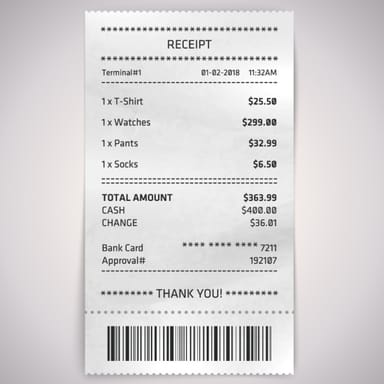

In [38]:
# img_url = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
img_url = "https://transcode-v2.app.engoo.com/image/fetch/f_auto,c_lfill,h_128,dpr_3/https://assets.app.engoo.com/images/5tGwSfHiJr9TfYuYnrXW9r.jpeg"
image = load_image(img_url)

display(image)


In [39]:
import requests
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering

processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to("cuda")

raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

question = "how many dogs are in the picture?"

inputs = processor(raw_image, question, return_tensors="pt").to("cuda")

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

/mnt/e/gg_ai_merbership_1th/hf_pytorch_ex/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


0


# 테스트

In [42]:
import torch
from transformers import AutoProcessor, AutoModelForVisualQuestionAnswering

model_id = "Salesforce/blip-vqa-base"
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForVisualQuestionAnswering.from_pretrained(
    model_id
).to(device)

# questions = [
#     "What animal is in the image?",
#     "What color is the animal?",
#     "Is the animal indoors or outdoors?"
# ]

questions = [
    "How much is the T-shirt?",
    # → 티셔츠 가격은 얼마인가?

    "What items were purchased?",
    # → 어떤 상품들이 구매되었는가?

    "What is the date of the transaction?",
    # → 거래 날짜는 언제인가?
]

for q in questions:
    inputs = processor(
        images=image,
        text=q,
        return_tensors="pt"  # pyTorch tensors로 변환
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=20
        )

    answer = processor.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print(q, "->", answer)

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

How much is the T-shirt? -> $ 19
What items were purchased? -> tickets
What is the date of the transaction? -> 17. 1. 2013


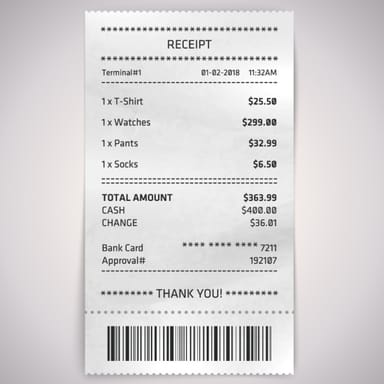

In [41]:
img_url = "https://transcode-v2.app.engoo.com/image/fetch/f_auto,c_lfill,h_128,dpr_3/https://assets.app.engoo.com/images/5tGwSfHiJr9TfYuYnrXW9r.jpeg"
image = load_image(img_url)

display(image)

## 확장 과제
- 영수증, 강의실, 제품 사진 등 도메인 이미지를 넣어본다.
- 같은 이미지에 질문 표현을 바꾸어 답변 안정성을 비교해본다.